# 25k 中文新闻句子数据集分析

**数据源**：`datasets/25k-chinese-news-sentences.csv` — 25,000 条中文新闻句子，来自 1,207 篇文章。

| 列 | 含义 |
|---|---|
| `id` | 句子 UUID |
| `article_id` | 所属文章 UUID |
| `paragraph_index` | 段落序号（文章内） |
| `sentence_index` | 句序号（段落内） |
| `sentence_text` | 句子文本 |
| `created_at` | 时间戳（UTC） |

**本 Notebook 分析内容**
1. 数据概览与质量检查（缺失、重复、结构一致性）
2. 文章结构统计（每文句数 / 段数）
3. 时间覆盖
4. 句长分析（字符数）
5. 用 `jieba` 做中文分词
6. 词汇量与词频分析
7. 小结与局限

环境：`pandas` / `matplotlib` / `jieba`（项目 `.venv`，Python 3.12）。

## 0. 环境与设置

In [1]:
import json
import os
import re
import statistics
from collections import Counter, defaultdict

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import jieba
import jieba.posseg as pseg

pd.set_option("display.max_colwidth", 140)

print("pandas", pd.__version__, "| matplotlib", matplotlib.__version__, "| jieba", jieba.__version__)
print("python", __import__("sys").version.split()[0])
print("kernel 工作目录:", os.getcwd())

pandas 3.0.5 | matplotlib 3.11.1 | jieba 0.42.1
python 3.12.12
kernel 工作目录: /Users/lishanhui/oss/chinese-news-reader/Chinese-news-sentences-dataset/notebooks


In [2]:
# 注册系统中可用的中文字体，保证图表里的中文正常显示
def find_cjk_font_files():
    dirs = [
        "/System/Library/Fonts",
        "/System/Library/Fonts/Supplemental",
        "/Library/Fonts",
        "/Library/Fonts/Supplemental",
        os.path.expanduser("~/Library/Fonts"),
    ]
    hits = []
    for d in dirs:
        if not os.path.isdir(d):
            continue
        try:
            names = os.listdir(d)
        except OSError:
            continue
        for fn in names:
            low = fn.lower()
            if any(k in low for k in ("pingfang", "hiragino", "heiti", "songti",
                                      "arial unicode", "noto", "wenquanyi", "wqy")):
                hits.append(os.path.join(d, fn))
    return hits

registered = []
for p in find_cjk_font_files():
    try:
        fm.fontManager.addfont(p)
        for f in fm.fontManager.ttflist:
            if f.fname == p and f.name not in registered:
                registered.append(f.name)
    except Exception:
        pass

print("已注册的中文字体:", registered[:6] if registered else "未找到（图表中文将显示为方块）")
if registered:
    plt.rcParams["font.sans-serif"] = registered[:3] + list(plt.rcParams.get("font.sans-serif", []))
    plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

# 常用绘图样式
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 4.5)

已注册的中文字体: ['Heiti TC', 'Heiti SC', 'Hiragino Sans GB', 'Hiragino Sans GB W3', '.Hiragino Sans GB Interface', 'Hiragino Sans GB W6']


In [3]:
# 解析数据路径：nbconvert 执行时内核的工作目录是 notebook 所在目录（notebooks/），
# 直接从项目根目录运行时用 datasets/；两种方式都兼容。
DATA_PATH = "datasets/25k-chinese-news-sentences.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("..", DATA_PATH)
BASE = os.path.dirname(os.path.abspath(DATA_PATH))
print("数据文件:", os.path.abspath(DATA_PATH))

df = pd.read_csv(DATA_PATH)
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
print(f"shape: {df.shape[0]:,} 行 × {df.shape[1]} 列")
df.head(3)

数据文件: /Users/lishanhui/oss/chinese-news-reader/Chinese-news-sentences-dataset/datasets/25k-chinese-news-sentences.csv
shape: 25,000 行 × 6 列


,id,article_id,paragraph_index,sentence_index,sentence_text,created_at
0,039a4ff7-64ff-4c62-9336-92220bd74a2a,130a811a-dc22-406b-909e-ee50a803fdaa,3,0,研究室首阶段重点项目，是针对文化通行证（SG Culture Pass）展开四年的追踪研究，分析这项措施是否有助培养本地艺术观众、支持艺术团体，以及促进本地文化艺术发展。,2026-09-02 07:36:30.673574+00:00
1,b27232c4-6202-4d9a-ac9b-6a17fc7f8091,130a811a-dc22-406b-909e-ee50a803fdaa,5,0,政府去年9月1日推出文化通行证计划，鼓励国人接触本地文化艺术。,2026-09-02 07:36:30.673574+00:00
2,0af993d4-a234-4d43-8bde-2e94ab154645,130a811a-dc22-406b-909e-ee50a803fdaa,5,1,18岁及以上的新加坡公民可通过Singpass登录官网，使用通行证的100元储值，购票观赏表演或参加各类导览、展览及工作坊。,2026-09-02 07:36:30.673574+00:00


## 1. 数据概览与质量检查

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "非空": df.notna().sum(),
    "缺失": df.isna().sum(),
    "唯一值数": df.nunique(),
})
summary

,dtype,非空,缺失,唯一值数
id,str,25000,0,25000
article_id,str,25000,0,1207
paragraph_index,int64,25000,0,166
sentence_index,int64,25000,0,31
sentence_text,str,25000,0,24337
created_at,"datetime64[us, UTC]",25000,0,1207


In [5]:
print("整行完全重复的行数:", df.duplicated().sum())

# 句子文本层面：完全相同的文本出现多次的次数
text_counts = df["sentence_text"].value_counts()
print("出现超过 1 次的句子文本数:", (text_counts > 1).sum())
print("这些重复文本累计占用的行数:", text_counts[text_counts > 1].sum())
print("重复占比（行）: {:.1%}".format(text_counts[text_counts > 1].sum() / len(df)))
print()
print("最常见的重复句子：")
for t, n in text_counts.head(5).items():
    print(f"  ×{n}  {t[:60]}…" if len(t) > 60 else f"  ×{n}  {t}")

# 同文本是否跨文章重复（新闻通稿复用常见）
print()
print("与‘本文章内重复’相关的行数（同文同段同句位）:",
      df.duplicated(subset=["article_id", "paragraph_index", "sentence_index"]).sum())

整行完全重复的行数: 0
出现超过 1 次的句子文本数: 408
这些重复文本累计占用的行数: 1071
重复占比（行）: 4.3%

最常见的重复句子：
  ×39  」
  ×11  千帆过尽才发现，壮龄正美丽。
  ×11  关注壮龄go!
  ×11  特制内容，加入壮龄go!
  ×11  社群，一起过好人生下半场。

与‘本文章内重复’相关的行数（同文同段同句位）: 0


In [6]:
# 结构一致性：每个 (文章, 段落) 内 sentence_index 是否从 0 开始且连续
g = df.groupby(["article_id", "paragraph_index"])["sentence_index"]
ok = 0
viol = 0
examples = []
for (art, para), idxs in g:
    idxs = sorted(idxs.tolist())
    good = idxs == list(range(len(idxs)))
    if good:
        ok += 1
    else:
        viol += 1
        if len(examples) < 3:
            examples.append(((art[:8], para), idxs[:8]))
print(f"(文章,段落) 分组总数: {ok + viol:,}")
print(f"sentence_index 从 0 连续递增的分组: {ok:,}")
print(f"不连续/不从 0 开始的分组: {viol:,}")
for (art, para), idxs in examples:
    print("  示例:", art, "para", para, "->", idxs)

(文章,段落) 分组总数: 13,796
sentence_index 从 0 连续递增的分组: 13,796
不连续/不从 0 开始的分组: 0


## 2. 文章结构统计

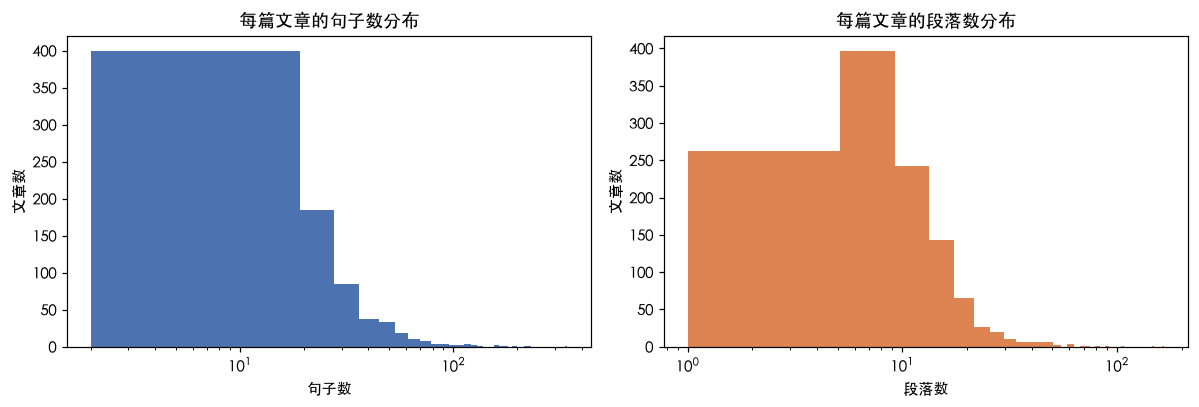

句子数最多的 3 篇文章:
                          article_id  句子数  段落数    平均句长字符
b7176640-4c70-4336-9b17-33b88b06faf2  343   28 26.711370
b49994b1-8370-4a2f-bb5f-ddd0dfae5e18  224  148 28.968750
5d493b84-2aad-47d2-a2e7-88fea41ce112  220  106 37.472727


In [7]:
art_stats = df.groupby("article_id").agg(
    句子数=("sentence_text", "size"),
    段落数=("paragraph_index", "nunique"),
    平均句长字符=("sentence_text", lambda s: s.str.len().mean()),
).reset_index()
art_stats.describe().T

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(art_stats["句子数"], bins=40, color="#4C72B0")
axes[0].set_title("每篇文章的句子数分布")
axes[0].set_xlabel("句子数"); axes[0].set_ylabel("文章数")
axes[1].hist(art_stats["段落数"], bins=40, color="#DD8452")
axes[1].set_title("每篇文章的段落数分布")
axes[1].set_xlabel("段落数"); axes[1].set_ylabel("文章数")
for a in axes:
    a.set_xscale("log") if art_stats[a.get_xlabel()].max() > 100 else None
plt.tight_layout(); plt.show()

# 长尾文章
print("句子数最多的 3 篇文章:")
print(art_stats.nlargest(3, "句子数").to_string(index=False))

count    13796.000000
mean         1.812119
std          1.286082
min          1.000000
50%          2.000000
90%          3.000000
99%          6.000000
max         31.000000

段落句子数分布：
1     6752
2     4598
3     1654
4      491
5      153
6       56
7       25
8       15
9       18
10       4
11       5
12       3


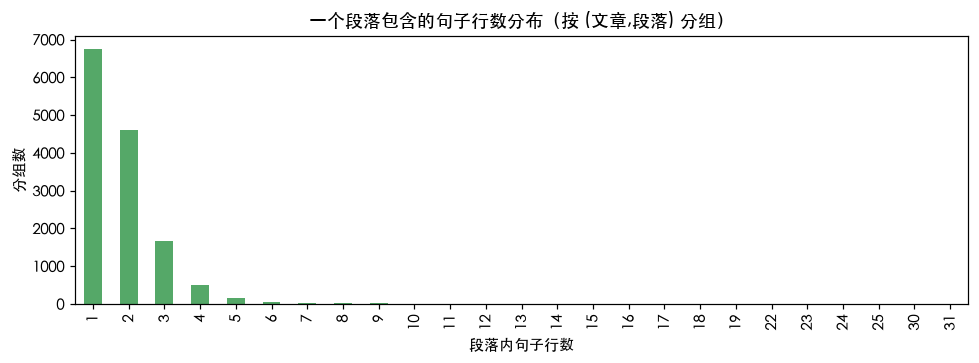

In [8]:
# 每个段落通常容纳几句？
rows_per_para = df.groupby(["article_id", "paragraph_index"]).size()
print(rows_per_para.describe(percentiles=[0.5, 0.9, 0.99]).to_string())
print()
print("段落句子数分布：")
print(rows_per_para.value_counts().sort_index().head(12).to_string())

rows_per_para.value_counts().sort_index().plot.bar(
    figsize=(9, 3.4), color="#55A868", title="一个段落包含的句子行数分布（按 (文章,段落) 分组）")
plt.xlabel("段落内句子行数"); plt.ylabel("分组数")
plt.tight_layout(); plt.show()

## 3. 时间覆盖

created_at 范围: 2026-08-09 17:12:30.579074+00:00 → 2026-09-02 07:36:30.673574+00:00
覆盖天数: 24
每篇文章是否共用同一时间戳（文章数 vs 时间戳数）: 1207 vs 1207


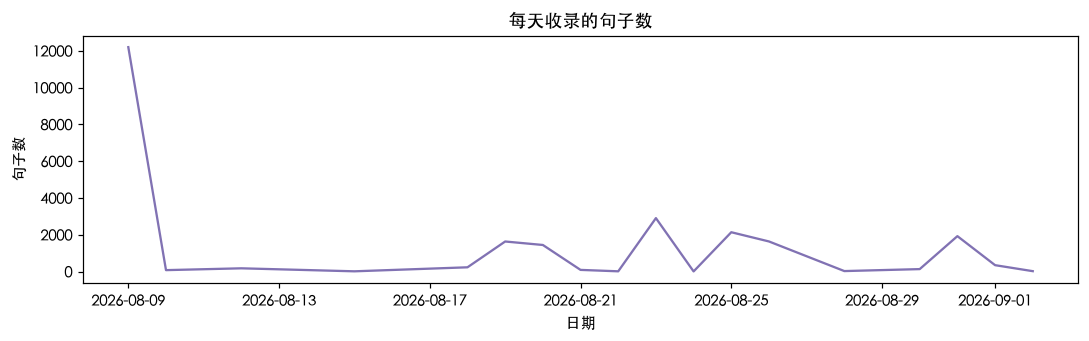

单日句子数 Top5：
created_at
2026-08-09    12200
2026-08-23     2904
2026-08-25     2137
2026-08-31     1924
2026-08-26     1635


In [9]:
print("created_at 范围:", df["created_at"].min(), "→", df["created_at"].max())
print("覆盖天数:", (df["created_at"].max() - df["created_at"].min()).days + 1)
print("每篇文章是否共用同一时间戳（文章数 vs 时间戳数）:",
      df["article_id"].nunique(), "vs", df["created_at"].nunique())

# 文章按天统计
by_day = df.groupby(df["created_at"].dt.date).size()
by_day.plot(figsize=(10, 3.2), color="#8172B3", title="每天收录的句子数")
plt.xlabel("日期"); plt.ylabel("句子数")
plt.tight_layout(); plt.show()
print("单日句子数 Top5：")
print(by_day.nlargest(5).to_string())

## 4. 句长分析（字符数）

In [10]:
def cjk_chars(t):
    return len(re.findall(r"[\u4e00-\u9fff]", t))

df["总字符数"] = df["sentence_text"].str.len()
df["汉字数"] = df["sentence_text"].apply(cjk_chars)

df[["总字符数", "汉字数"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
总字符数,25000.0,45.81816,25.491634,1.0,7.0,13.0,28.0,41.0,59.0,93.0,126.01,301.0
汉字数,25000.0,36.80792,20.131566,0.0,4.0,10.0,22.0,34.0,48.0,74.0,98.00,267.0


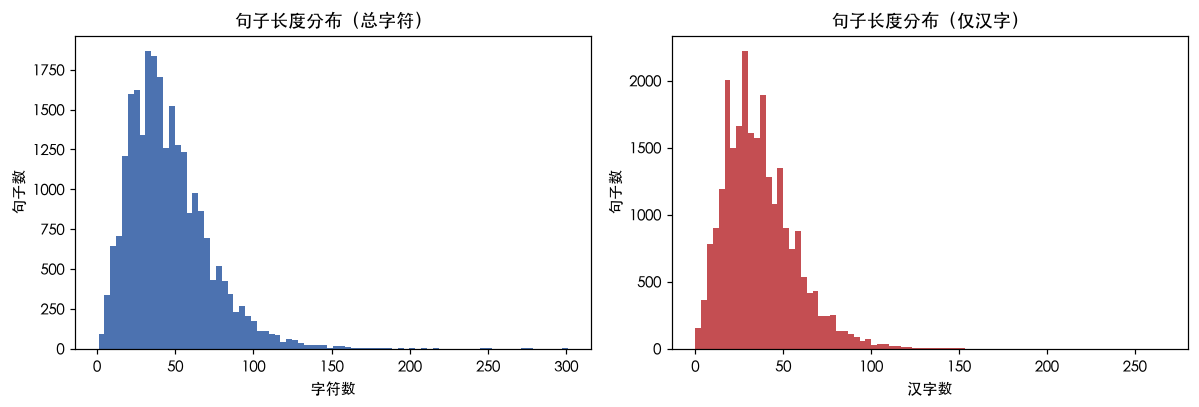

最长 5 句（总字符数）：
  [301字] 去年7月18日刘慧被查，今年3月26日她被开除党籍，通报称她丧失理想信念，背弃初心使命，贯彻落实党中央重大决策部署打折扣、搞变通，结交政治骗子，匿名诬告他人，对…
  [278字] We have information that Moonshot AI distilled Anthropic’s Fable for the develop…
  [277字] The United States’ declaration of new economic sanctions on Iran is far more tha…
  [273字] 据央视新闻画面，出席大会的中共元老在主席台第一排就坐，包括中国前总理温家宝（下月满84岁）、中国全国政协前主席贾庆林（86岁）、中国全国人大常委会前委员长张德江…
  [251字] 在循证诊疗决策支持方面，医生输入临床问题后，协作体可自动将复杂问题拆解为多个子任务，分别检索最新文献与权威指南，并在交叉比对基础上生成结构化的循证建议报告，同时…

最短 5 句：
  [1字] 」
  [1字] 」
  [1字] 」
  [1字] 」
  [1字] 」


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(df["总字符数"], bins=80, color="#4C72B0")
axes[0].set_title("句子长度分布（总字符）")
axes[0].set_xlabel("字符数"); axes[0].set_ylabel("句子数")
axes[1].hist(df["汉字数"], bins=80, color="#C44E52")
axes[1].set_title("句子长度分布（仅汉字）")
axes[1].set_xlabel("汉字数"); axes[1].set_ylabel("句子数")
plt.tight_layout(); plt.show()

print("最长 5 句（总字符数）：")
longest = df.nlargest(5, "总字符数")
for _, r in longest.iterrows():
    print(f"  [{r['总字符数']}字] {r['sentence_text'][:80]}…")
print()
print("最短 5 句：")
shortest = df.nsmallest(5, "总字符数")
for _, r in shortest.iterrows():
    print(f"  [{r['总字符数']}字] {r['sentence_text'][:80]}")

## 5. 用 jieba 做中文分词

In [12]:
sample = df.loc[df["sentence_text"].str.len().between(25, 60), "sentence_text"].iloc[0]
print("示例句子：", sample)
print()
print("jieba 精确模式分词：", " / ".join(jieba.lcut(sample)))
print()
print("带词性的切分（posseg）：")
for w, flag in pseg.cut(sample):
    print(f"  {w}  [{flag}]")

Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/x4/mkl50wcj6rz55z_7br5grsy00000gn/T/jieba.cache


示例句子： 政府去年9月1日推出文化通行证计划，鼓励国人接触本地文化艺术。



Loading model cost 0.386 seconds.


Prefix dict has been built successfully.


jieba 精确模式分词： 政府 / 去年 / 9 / 月 / 1 / 日 / 推出 / 文化 / 通行证 / 计划 / ， / 鼓励 / 国人 / 接触 / 本地 / 文化 / 艺术 / 。

带词性的切分（posseg）：
  政府  [n]
  去年  [t]
  9  [m]
  月  [m]
  1  [m]
  日  [m]
  推出  [v]
  文化  [n]
  通行证  [n]
  计划  [n]
  ，  [x]
  鼓励  [v]
  国人  [n]
  接触  [v]
  本地  [r]
  文化  [n]
  艺术  [n]
  。  [x]


In [13]:
# 全文分词。为节省时间用一个精简版词表，不启用并行。
# 停用/过滤规则：去掉空白、纯标点、单字虚词留在后面单独讨论。
PUNCT_RE = re.compile(r"^[\s\u3000-\u303f\uff00-\uffef\u2000-\u206f\u00a0…—–‘’“”·]+$")

def is_punct(w):
    return PUNCT_RE.match(w) is not None or not re.search(r"[\w\u4e00-\u9fff]", w)

import time
t0 = time.time()

# 只跑 posseg 一次，同时得到词与词性（比 cut 稍慢但信息更全）
tagged = []
all_tokens = []          # 所有非标点 token
content_tokens = []      # 内容词（名/动/形/副词等主要词性）

CONTENT_PREFIX = ("n", "v", "a", "d")  # 名词/动词/形容词/副词 大类（含 nz, vn, ad…）
for sent in df["sentence_text"].tolist():
    for w, flag in pseg.cut(sent):
        w = w.strip()
        if not w or is_punct(w):
            continue
        all_tokens.append(w)
        if flag.startswith(CONTENT_PREFIX) and len(w) > 1:
            content_tokens.append(w)

print(f"分词完成，耗时 {time.time()-t0:.1f}s")
print(f"句子数: {len(df):,} | 非标点 token 总数: {len(all_tokens):,} | 内容词 token 数: {len(content_tokens):,}")

分词完成，耗时 11.6s
句子数: 25,000 | 非标点 token 总数: 538,872 | 内容词 token 数: 282,552


count    25000.000000
mean        21.287760
std         11.342791
min          0.000000
1%           3.000000
25%         13.000000
50%         20.000000
75%         28.000000
99%         56.000000
max        142.000000


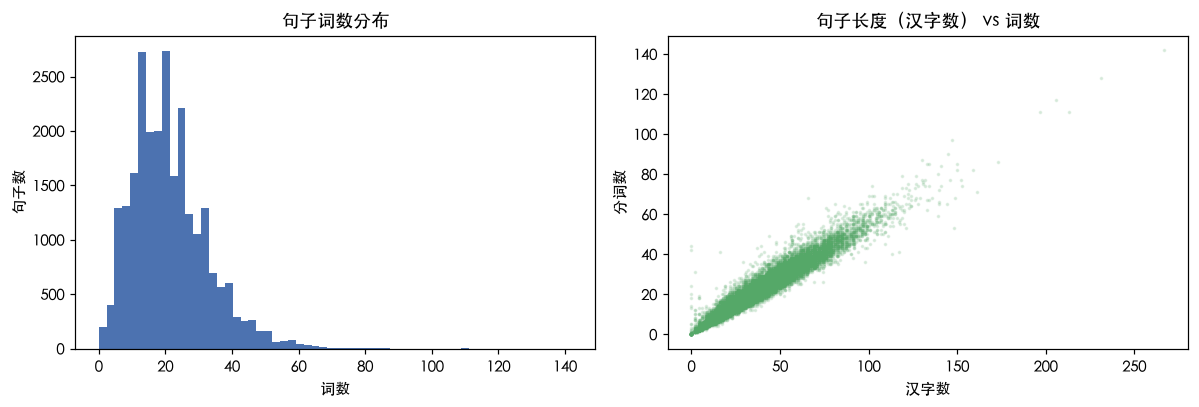

汉字数与词数相关系数: 0.9663


In [14]:
# 每句词数
df["分词数"] = df["sentence_text"].apply(lambda s: len([w for w in jieba.lcut(s) if not is_punct(w.strip())]))
print(df["分词数"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(df["分词数"], bins=60, color="#4C72B0")
axes[0].set_title("句子词数分布")
axes[0].set_xlabel("词数"); axes[0].set_ylabel("句子数")
axes[1].scatter(df["汉字数"], df["分词数"], s=2, alpha=0.15, color="#55A868")
axes[1].set_title("句子长度（汉字数） vs 词数")
axes[1].set_xlabel("汉字数"); axes[1].set_ylabel("分词数")
plt.tight_layout(); plt.show()
print("汉字数与词数相关系数:", round(df[["汉字数", "分词数"]].corr().iloc[0, 1], 4))

## 6. 词汇量与词频

In [15]:
from collections import Counter
tok_counter = Counter(all_tokens)
cont_counter = Counter(content_tokens)

print(f"语料 token 总数（非标点）: {len(all_tokens):,}")
print(f"词汇量（去重 token 数）: {len(tok_counter):,}")
print(f"内容词（>1 字的名/动/形/副词）词汇量: {len(cont_counter):,}")
print(f"词汇多样性（type/token 比）: {len(tok_counter)/len(all_tokens):.3f}")

# 未过滤时排第一的是功能词——这正是下面要做过滤的原因
w0, c0 = tok_counter.most_common(1)[0]
print(f"（参考）未过滤最高频词: {w0} ×{c0:,}")

语料 token 总数（非标点）: 538,872
词汇量（去重 token 数）: 45,514
内容词（>1 字的名/动/形/副词）词汇量: 30,260
词汇多样性（type/token 比）: 0.084
（参考）未过滤最高频词: 的 ×25,565


### 6.1 过滤：排除国家/地区名、常见虚词、含拉丁字母的词

“全词频”被虚词（的 ×2.5 万+）主导。为了得到更有信息量的**主题词**，在内容词（多字名词/动词/形容词/副词）基础上再做三层过滤：

1. **常见虚词 / 功能词 / 轻动词**（的、在、是、可能、表示、认为…）→ 见下方 `STOPWORDS`，可直接增删；
2. **国家与地区名**（中国、美国、新加坡、伊朗…）→ 见 `COUNTRIES`；
3. **含拉丁字母或纯外文**的 token（AI、5G、Singpass、Moonshot…）→ `has_latin()`。

In [16]:
# 1) 常见虚词/功能词与轻动词
STOPWORDS = set('''
的 了 在 是 和 与 或 及 等 这 那 我 你 他 她 它 们 个 种 些 上 下 中 内 外 前 后 左 右
也 都 就 还 又 再 很 更 最 太 已 将 会 能 要 可 应 该 不 没 无 非 若 如 则 并 且 但 因 为 从 到 向 对 于 把 被 让 以 之 其 而 所
我们 你们 他们 她们 它们 这个 那个 这些 那些 这样 那样 这里 那里 什么 怎么 如何 为什么
因为 所以 但是 虽然 而且 或者 以及 并且 如果 由于 因此 然而 同时 此外 其中 之间 之后 之前 以后 以前 目前 当前 现在 未来
已经 正在 一直 仍然 依然 可能 可以 应该 必须 能够 需要 将会 没有 不是 还有 对于 关于 为了 除了 作为 根据 按照 随着 通过 进行 开展 成为
表示 认为 指出 强调 宣布 决定 希望 要求 包括 属于 具有 相关 有关 比如 例如 方面 情况 时候
'''.split())

# 2) 国家与地区名
COUNTRIES = set('''
中国 美国 新加坡 伊朗 日本 韩国 朝鲜 俄罗斯 英国 法国 德国 印度 以色列 巴基斯坦 土耳其 乌克兰 白俄罗斯
波兰 意大利 西班牙 葡萄牙 荷兰 比利时 瑞士 瑞典 奥地利 希腊 匈牙利 捷克 芬兰 挪威 丹麦 爱尔兰 澳大利亚 加拿大 新西兰
印尼 马来西亚 泰国 越南 菲律宾 缅甸 柬埔寨 老挝 文莱 尼泊尔 孟加拉 斯里兰卡 马尔代夫 不丹 蒙古
哈萨克 乌兹别克 吉尔吉斯 塔吉克 沙特 阿联酋 卡塔尔 科威特 巴林 阿曼 也门 约旦 伊拉克 叙利亚 黎巴嫩 巴勒斯坦
埃及 利比亚 突尼斯 阿尔及利亚 摩洛哥 苏丹 埃塞俄比亚 肯尼亚 尼日利亚 南非 加纳 坦桑尼亚
巴西 阿根廷 墨西哥 智利 秘鲁 哥伦比亚 委内瑞拉 古巴 台湾 香港 澳门
'''.split())

# 3) 含拉丁字母（AI、5G、Singpass…）或纯外文的 token
def has_latin(w):
    return re.search(r"[A-Za-z]", w) is not None

# 内容词（多字名/动/形/副词）→ 再排除以上三类
topical = [w for w in content_tokens
           if w not in STOPWORDS and w not in COUNTRIES and not has_latin(w)]
top_counter = Counter(topical)

removed = Counter()
for w, c in cont_counter.items():
    if w in STOPWORDS:
        removed["停用词/虚词"] += c
    elif w in COUNTRIES:
        removed["国家/地区名"] += c
    elif has_latin(w):
        removed["含拉丁字母"] += c
print(f"内容词 token 数: {len(content_tokens):,} → 过滤后: {len(topical):,}（移除 {len(content_tokens)-len(topical):,}）")
print("按类别移除的 token 次数:", dict(removed))
print(f"过滤后词汇量: {len(top_counter):,}")
for w in ("AI", "中国", "美国", "新加坡", "伊朗", "的"):
    print(f"  例: {w!r} 原始次数 ×{cont_counter.get(w, tok_counter.get(w, 0)):,} → 已排除")

内容词 token 数: 282,552 → 过滤后: 263,388（移除 19,164）
按类别移除的 token 次数: {'国家/地区名': 8587, '停用词/虚词': 10499, '含拉丁字母': 78}
过滤后词汇量: 30,134
  例: 'AI' 原始次数 ×2,115 → 已排除
  例: '中国' 原始次数 ×2,322 → 已排除
  例: '美国' 原始次数 ×1,494 → 已排除
  例: '新加坡' 原始次数 ×997 → 已排除
  例: '伊朗' 原始次数 ×610 → 已排除
  例: '的' 原始次数 ×25,565 → 已排除


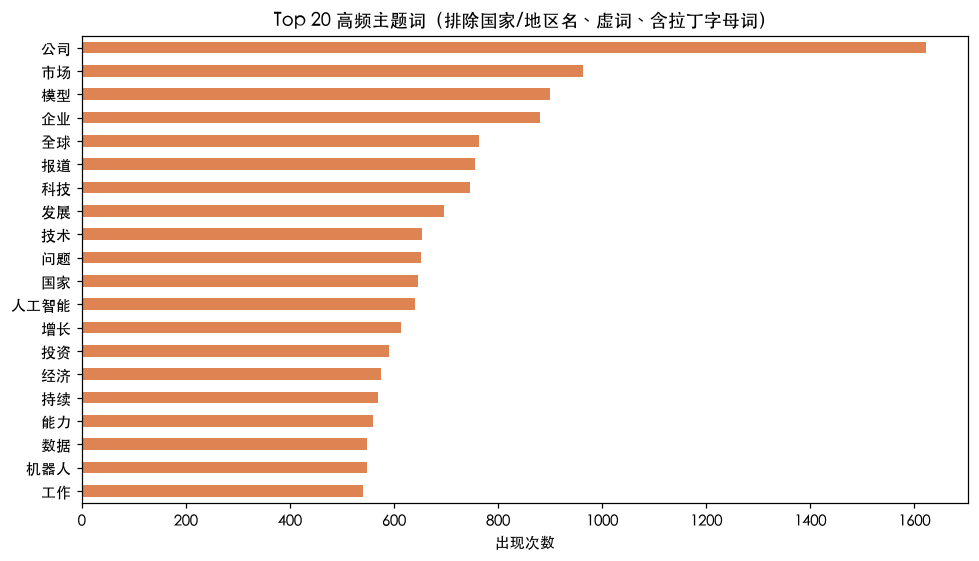

Top 30（过滤后主题词）:
  公司  ×1,622
  市场  ×964
  模型  ×900
  企业  ×880
  全球  ×763
  报道  ×755
  科技  ×747
  发展  ×697
  技术  ×653
  问题  ×652
  国家  ×647
  人工智能  ×641
  增长  ×614
  投资  ×591
  经济  ×575
  持续  ×569
  能力  ×560
  数据  ×549
  机器人  ×549
  工作  ×541
  提供  ×533
  合作  ×512
  计划  ×508
  政府  ×499
  发布  ×489
  支持  ×488
  显示  ×482
  影响  ×472
  超过  ×460
  领域  ×454


In [17]:
top20 = pd.Series(dict(top_counter.most_common(20)))
fig, ax = plt.subplots(figsize=(9, 5.2))
top20.iloc[::-1].plot.barh(ax=ax, color="#DD8452")
ax.set_title("Top 20 高频主题词（排除国家/地区名、虚词、含拉丁字母词）")
ax.set_xlabel("出现次数")
plt.tight_layout(); plt.show()

print("Top 30（过滤后主题词）:")
for w, c in top_counter.most_common(30):
    print(f"  {w}  ×{c:,}")

In [18]:
# 导出词频表：全词（未过滤）+ 过滤后主题词。
# 数据位于 <项目根>/datasets/ 下，因此把结果输出到 <项目根>/outputs/。
project_root = os.path.dirname(BASE) if os.path.basename(BASE) == "datasets" else BASE
out_dir = os.path.join(project_root, "outputs")
os.makedirs(out_dir, exist_ok=True)
pd.DataFrame(tok_counter.most_common(), columns=["词", "频次"]).to_csv(
    os.path.join(out_dir, "word_frequency_all.csv"), index=False)
pd.DataFrame(top_counter.most_common(), columns=["词", "频次"]).to_csv(
    os.path.join(out_dir, "word_frequency_topical.csv"), index=False)
print("已导出到", out_dir)
print("  word_frequency_all.csv      （全部词频，未过滤）")
print("  word_frequency_topical.csv  （过滤：国家/地区名、虚词、含拉丁字母词）")

已导出到 /Users/lishanhui/oss/chinese-news-reader/Chinese-news-sentences-dataset/outputs
  word_frequency_all.csv      （全部词频，未过滤）
  word_frequency_topical.csv  （过滤：国家/地区名、虚词、含拉丁字母词）


## 7. 小结与局限

**关键发现**
1. **规模与结构**：25,000 句来自 1,207 篇文章，无缺失、无空值、无整行重复。平均每文约 20.7 句（中位数 14，最多 343）；段落级 `(文章, 段落)` 共 13,796 组，`sentence_index` 全部从 0 连续递增，结构字段完全自洽。
2. **句子复用**：408 个句子文本出现多次，涉及 1,071 行（4.3%）；其中出现最多的是 `」`（39 次）等标点/碎片，说明切分残留了少量纯标点行（54 行总长 ≤2 字符；67 行完全不含汉字，含英文/外文句）。
3. **句长**：平均每句 45.8 字符（其中汉字约 36.8 个），中位数 41 字符；分布右偏，最长 301 字符。汉字数与词数高度相关（r = 0.97）。
4. **词汇**：去除标点后共 538,872 个 token，词汇量 45,514，type/token 比约 0.084；未过滤时最高频词为功能词“的”（×25,565，×在 7,779、×和 4,779…）。
5. **主题线索（过滤后）**：在内容词基础上排除**国家/地区名**（中国 ×2,322、美国 ×1,494、新加坡 ×997、伊朗 ×610…）、**常见虚词/轻动词**与**含拉丁字母词**（AI ×2,115 等），共移除 19,164 个 token（国家/地区 8,587、虚词类 10,499、拉丁字母 78）。过滤后 Top 词为：公司、市场、模型、企业、全球、科技、发展、技术、人工智能、机器人、数据、投资、经济… 显示语料以科技/商业/国际报道为主。
6. **时间**：覆盖 2026-08-09 → 09-02 共 24 天；时间戳数 = 文章数（1,207），即每篇文章一个时间戳（批量收录时间），单日 08-09 收录 12,200 句（49%），不代表真实发布时间。

**局限与建议**
- 无文章标题/分类/来源字段，主题只能靠词频推断；正文明显含英文等非中文句子，若做纯中文 NLP 需先过滤。
- 少数段落组含 6–31 个“句子行”（148 组、1,361 行、占 5.4%），可能是引文/列表未细分，结构统计存在轻微噪声。
- `jieba` 是通用词典，专名（人名/机构/产品）可能切分不佳；可加自定义词典（如 `jieba.add_word`）改进。
- 词频结果已导出：`outputs/word_frequency_all.csv`（全词，未过滤）与 `outputs/word_frequency_topical.csv`（已排除国家/地区名、虚词、含拉丁字母词），可供下游分析直接复用；过滤名单（`STOPWORDS` / `COUNTRIES`）在 Notebook 6.1 节中可直接增删。